In [1]:
import jax
# jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
from jax import config, jit, random, grad, vmap, flatten_util, hessian

from jax import random

import scipy.integrate as integrate

from thermo_oscillator_network_fns import energy_network, setup_integration, integrate_dofs

from scipy.stats import multivariate_normal

import os

import matplotlib.pyplot as plt

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


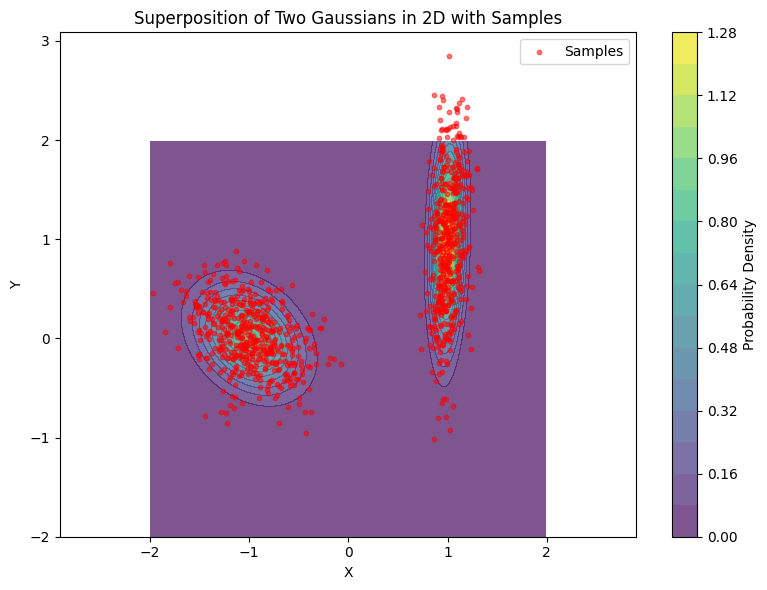

In [2]:
def sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key):
    """
    Samples from a superposition of two Gaussian distributions in 2D using JAX.
    """
    key1, key2, key3 = random.split(key, 3)
    
    # Sample from both Gaussians
    samples1 = random.multivariate_normal(key1, mu1, sigma1, shape=(n_samples,))
    samples2 = random.multivariate_normal(key2, mu2, sigma2, shape=(n_samples,))
    
    # Generate random numbers to decide which sample to keep
    choices = random.uniform(key3, shape=(n_samples,)) < p1
    
    # Select samples based on the choices
    samples = jnp.where(choices[:, None], samples1, samples2)
    
    return samples

def gaussian_pdf(x, y, mu, sigma):
    """Compute the PDF of a 2D Gaussian distribution."""
    pos = jnp.dstack((x, y))
    return multivariate_normal.pdf(pos, mean=mu, cov=sigma)

# Parameters for the first Gaussian
mu1 = jnp.array([1, 1])
sigma1 = jnp.array([[0.01, 0.01], [0.01, 0.4]])

# Parameters for the second Gaussian
mu2 = jnp.array([-1, 0])
sigma2 = jnp.array([[0.1, -0.03], [-.03, 0.1]])

# Probability of sampling from the first Gaussian
p1 = 0.5

# Number of samples to generate
n_samples = 1000

# JAX random key
key = random.PRNGKey(0)

# Generate samples
samples = sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key)

# Create a grid for the contour plot
x_lim = 2
y_lim = 2
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]

# Compute the PDF for both Gaussians
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)

# Combine the PDFs according to the mixture weights
z = p1 * z1 + (1 - p1) * z2

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the contour of the combined distribution
plt.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(label='Probability Density')

# Plot the samples
plt.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')

plt.title('Superposition of Two Gaussians in 2D with Samples')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [3]:
# # # Duffing params
# k_lin= jnp.array([1., 1.,1.,1.])
# k_duff = jnp.array([0., 0.,0.,0.])
# c_lin = jnp.array([.0,.0,.0])
# c_optomech = jnp.array([0., 0.,0.])
# connectivity = jnp.array([[0, 1],[1, 2],[2, 3]])

# marginalized_dofs = jnp.array([1,2])
# non_marginalized_dofs = jnp.array([0,3])

In [4]:
# # # Duffing params
k_b = 1.
T = 100.
from dataclasses import dataclass

@dataclass
class DuffingParams:
    k_b: float = 1.
    T: float = 100.
    m: jnp.ndarray = jnp.array([1., 1., 1.])
    eig_freq: jnp.ndarray = jnp.array([1., 1., 1.])
    k_lin: jnp.ndarray = None
    k_duff: jnp.ndarray = jnp.array([1., 1., 1.])
    c_lin: jnp.ndarray = jnp.zeros(2)
    c_optomech: jnp.ndarray = jnp.array([1., 1.])
    connectivity: jnp.ndarray = jnp.array([[0, 1], [1, 2]])
    marginalized_dofs: jnp.ndarray = jnp.array([1])
    non_marginalized_dofs: jnp.ndarray = jnp.array([0, 2])

    def __post_init__(self):
        if self.k_lin is None:
            self.k_lin = self.eig_freq**2 * self.m
            
            
            
# a model is a graph G=(E,V) with a set of edges E and a set of vertices V representing springs and dofs
# a constant is a Real number
# a stiffness is an Real number
# a spring is a tuple of two dofs
# a spring has an associated stiffness
# a dof is an int in [0,N-1]
# a dof has a mass, self-spring, partner-spring, and optomechanical spring (TBD)
# a dof has a linear constant and an optomechanical constant 
# a network of dofs is a list of dofs with an associated connectivity matrix
# a network has a connectivity matrix
# a dof is a node in the network
# a dof has a mass, 
# Initialize the dataclass
params = DuffingParams()

m = jnp.array([1., 1., 1.])
eig_freq = jnp.array([1., 1., 1.])
k_lin= eig_freq**2*m
k_duff = jnp.array([1., 1., 1.])
c_lin = jnp.zeros(2)
c_optomech = jnp.array([1., 1.])
connectivity = jnp.array([[0, 1], [1, 2]])

marginalized_dofs = jnp.array([1])
non_marginalized_dofs = jnp.array([0, 2]) 

In [5]:
# # Duffing params
# m = jnp.array([1., 1.])
# eig_freq = jnp.array([1., 1.])
# k_lin= eig_freq**2*m
# k_duff = jnp.array([1., 1.0])
# c_lin = jnp.array([.3])*k_lin[0]
# c_optomech = jnp.array([1.])
# connectivity = jnp.array([[0, 1]])

# marginalized_dofs = None #jnp.array([0,3])
# non_marginalized_dofs = jnp.array([0,1]) 

In [6]:
# # Duffing params
# k_lin= jnp.array([1., 1.,10.,1.,1.])+1
# k_duff = jnp.array([0., .0, .0, .0, .0])+2

# connectivity = jnp.array([[0, 1], [1 , 2], [2, 3], [3, 4]])
# c_lin = jnp.array([.0, .0, .0,0.])+2
# c_optomech = jnp.array([0., .0, .0,0.])+2


# marginalized_dofs = jnp.array([1,2,3])
# non_marginalized_dofs = jnp.array([0,4])

In [7]:
# integration_limits = (-2,2)
# num_integration_points = 10
# if marginalized_dofs is not None:
#     inegrator = setup_integration(marginalized_dofs, integration_limits=integration_limits, num_integration_points=num_integration_points)
# else:
#     inegrator = setup_integration(non_marginalized_dofs, integration_limits=integration_limits
# , num_integration_points=num_integration_points)

In [8]:
integration_limits = (-2, 2)
num_integration_points = 10
if marginalized_dofs is not None:
    get_integrands = setup_integration(marginalized_dofs, integration_limits=integration_limits, num_integration_points=10)
    sign_hess = 1
else:
    get_integrands = setup_integration(non_marginalized_dofs, integration_limits=(-2, 2), num_integration_points=10)
    sign_hess = -1


In [9]:
if marginalized_dofs is not None:
    energy_network_marg = integrate_dofs(get_integrands, energy_network, marginalized_dofs, non_marginalized_dofs)
else:
    energy_network_marg = energy_network

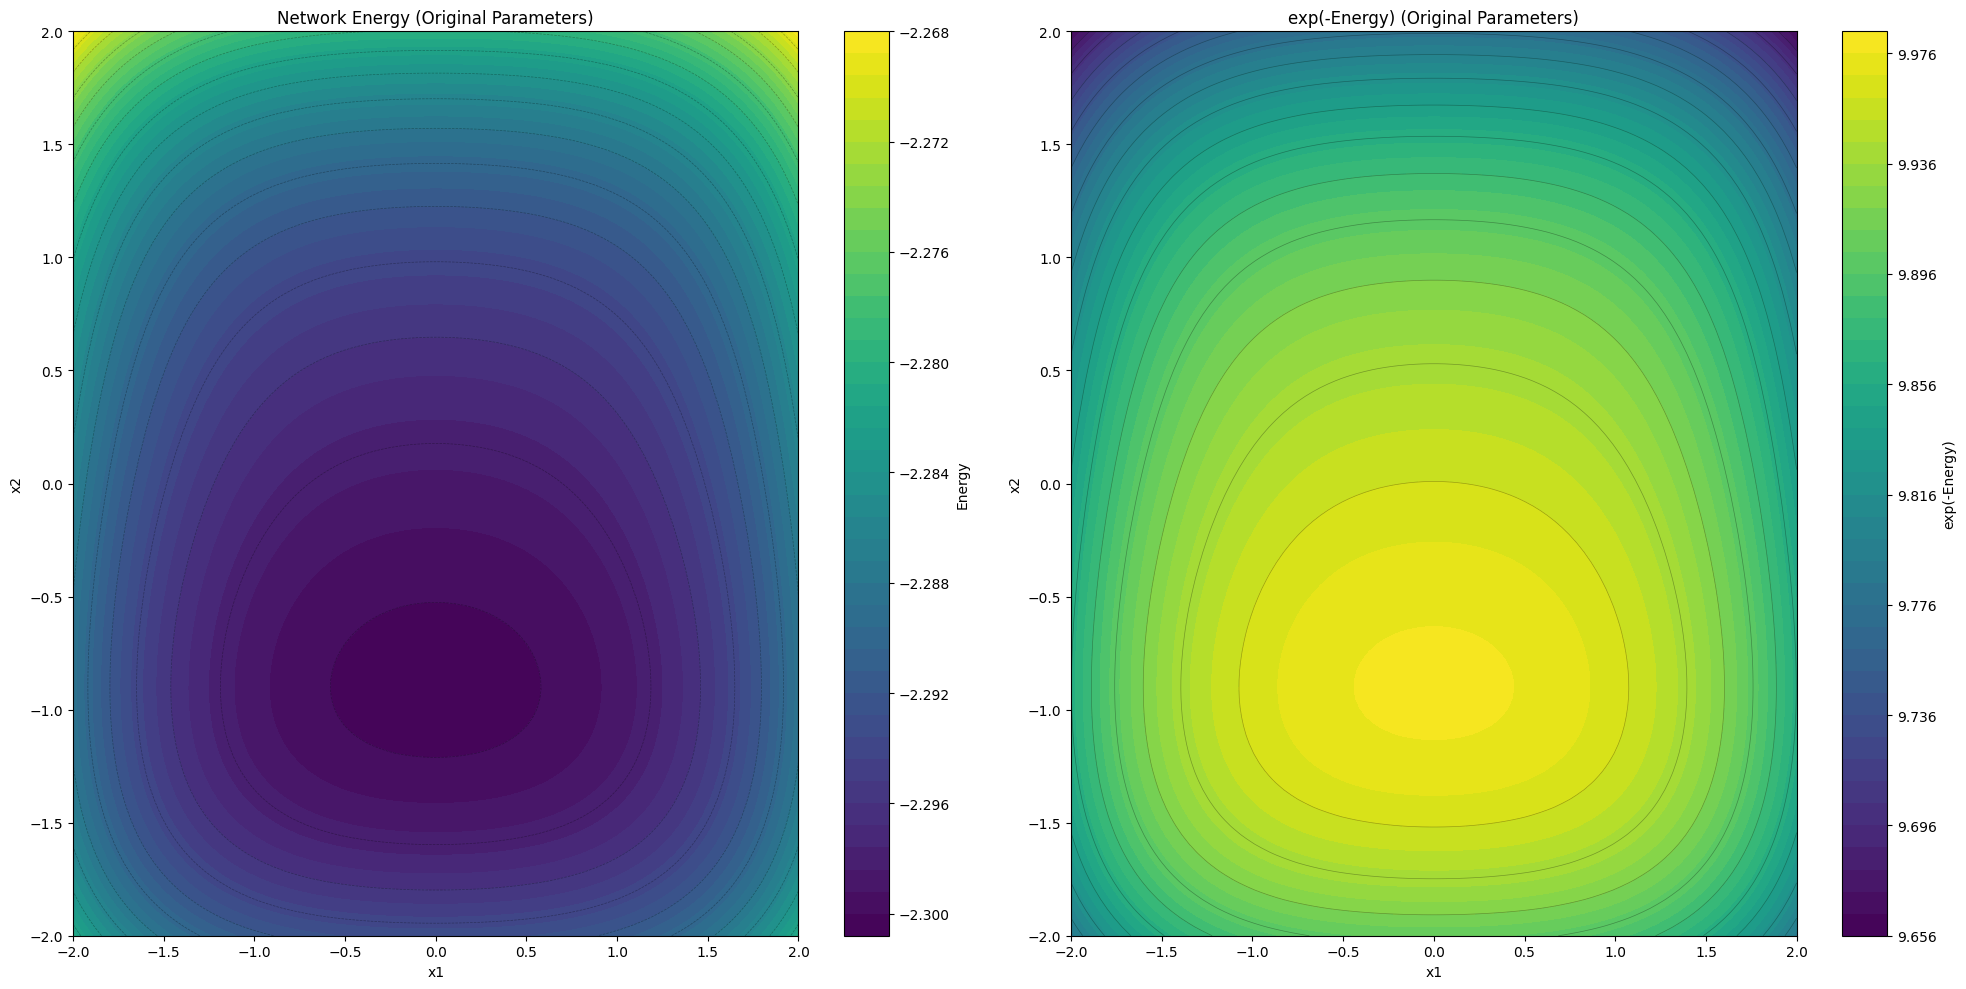

Original parameters: k_lin=[1. 1. 1.], k_duff=[1. 1. 1.], c_lin=[0. 0.], c_optomech=[1. 1.]
Integration limits: (-2, 2)


In [10]:
# Define the grid for plotting using integration limits
x1_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
x2_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

# Calculate energy values for original parameters
energy_values_original = vmap(lambda x1, x2: -1*sign_hess*energy_network_marg(jnp.array([x1, x2]), k_lin, k_duff, c_lin, c_optomech, connectivity,k_b,T))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate exp(-energy) values
exp_neg_energy = jnp.exp(-energy_values_original)

# Create the plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot original energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
ax1.set_title("Network Energy (Original Parameters)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
cbar1 = fig.colorbar(contour1, ax=ax1, label='Energy')

# Add contour lines for better visibility of energy levels
ax1.contour(X1, X2, energy_values_original, levels=20, colors='k', alpha=0.3, linewidths=0.5)

# Plot exp(-energy)
contour2 = ax2.contourf(X1, X2, exp_neg_energy, levels=50, cmap='viridis')
ax2.set_title("exp(-Energy) (Original Parameters)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
cbar2 = fig.colorbar(contour2, ax=ax2, label='exp(-Energy)')

# Add contour lines for better visibility of exp(-energy) levels
ax2.contour(X1, X2, exp_neg_energy, levels=20, colors='k', alpha=0.3, linewidths=0.5)

plt.tight_layout()
plt.show()

# Print original parameter values for reference
print(f"Original parameters: k_lin={k_lin}, k_duff={k_duff}, c_lin={c_lin}, c_optomech={c_optomech}")
print(f"Integration limits: {integration_limits}")

In [11]:
# Define lists of optimized and non-optimized parameters
optimized_params = [k_lin, k_duff,c_optomech,c_lin]
non_optimized_params = []

def loss_fn(*opt_params):
    # Combine optimized and non-optimized parameters
    all_params = list(opt_params) + non_optimized_params
    k_lin, k_duff, c_lin, c_optomech = all_params

    def current_network_energy(x):
        return energy_network_marg(x, k_lin, k_duff, c_lin, c_optomech, connectivity,k_b,T)
    
    current_score = grad(current_network_energy)
    current_score2 = hessian(current_network_energy)

    
    current_score_loss_per_sample = lambda x: (sign_hess*jnp.trace(current_score2(x)) + 1/2 * jnp.sum(current_score(x)**2))/n_samples   
    return jnp.sum(vmap(current_score_loss_per_sample)(samples))

# Compute gradients of the loss with respect to optimized parameters
@jit
def grad_loss(*opt_params):
    return grad(loss_fn, argnums=range(len(opt_params)))(*opt_params)

# Compute Hessian of the loss function for optimized parameters
@jit
def hessian_loss(*opt_params):
    return hessian(loss_fn, argnums=range(len(opt_params)))(*opt_params)

In [12]:
num_iterations = 30000

learning_rate = 0.1

clip_value = None

# Initial values for optimized parameters
opt_params = [param.copy() for param in optimized_params]

# List to store loss values
loss_values = []

use_hessian = True

# Optimization loop
for i in range(num_iterations + 1):
    # Compute gradients and Hessian
    grads = grad_loss(*opt_params)
   
    
    # Flatten gradients
    flat_grads = jnp.concatenate([g.ravel() for g in grads])
    # print(flat_grads)
    
    
    if use_hessian:
        hess = hessian_loss(*opt_params)
        # Flatten Hessian
        flat_hess = jnp.vstack([jnp.hstack([jnp.atleast_2d(h) for h in hess_row]) for hess_row in hess])

        # Compute update direction (solving Hx = -g)
        update = jnp.linalg.solve(flat_hess + 1e-4 * jnp.eye(flat_hess.shape[0]), -flat_grads)
    else:
        update = -flat_grads
    

    current_index = 0
    
    for l, param in enumerate(opt_params):
        param_size = param.size
        param_shape = param.shape
        
        # Slice the update vector for the current parameter
        param_update = update[current_index:current_index + param_size].reshape(param_shape)
        
        new_param = param + learning_rate * param_update
        

        if clip_value is not None:
            opt_params[l] = jnp.maximum(new_param, clip_value)
        else:
            opt_params[l] = new_param
        
        # Move to the next section of the update vector
        current_index += param_size
    
      
    # Save and print progress every 10 iterations
    if i % 1 == 0 or i == num_iterations:
        current_loss = loss_fn(*opt_params)
        loss_values.append(jnp.float32(current_loss))
        all_params = opt_params + non_optimized_params
        print(f"Iteration {i}, Loss: {current_loss}")
        print(f"k_lin: {all_params[0]}, k_duff: {all_params[1]}, c_lin: {all_params[2]}, c_optomech: {all_params[3]}")

k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt = opt_params

Iteration 0, Loss: -0.09167836606502533
k_lin: [2.4608574 1.0025706 2.6095765], k_duff: [6.5768843 1.0051905 4.03767  ], c_lin: [2.9204106 3.1254673], c_optomech: [ 0.14531946 -0.3111781 ]
Iteration 1, Loss: -0.1581885814666748
k_lin: [3.8836203 1.0099266 4.1954656], k_duff: [12.098232   1.0200047  6.996485 ], c_lin: [4.7976923 5.2106447], c_optomech: [ 0.29046357 -0.6268081 ]
Iteration 2, Loss: -0.22218430042266846
k_lin: [5.26884   1.0216191 5.7583222], k_duff: [17.564812   1.0434847  9.878567 ], c_lin: [6.634481  7.2578497], c_optomech: [ 0.43521482 -0.947721  ]
Iteration 3, Loss: -0.28382015228271484
k_lin: [6.61706   1.0372163 7.298786 ], k_duff: [22.977377   1.0747188 12.685986 ], c_lin: [8.433195 9.269162], c_optomech: [ 0.5794167 -1.2746953]
Iteration 4, Loss: -0.34323734045028687
k_lin: [7.9288197 1.056304  8.817484 ], k_duff: [28.336674   1.1128422 15.420758 ], c_lin: [10.196059 11.246453], c_optomech: [ 0.7229646 -1.6084553]
Iteration 5, Loss: -0.4005654454231262
k_lin: [ 9.

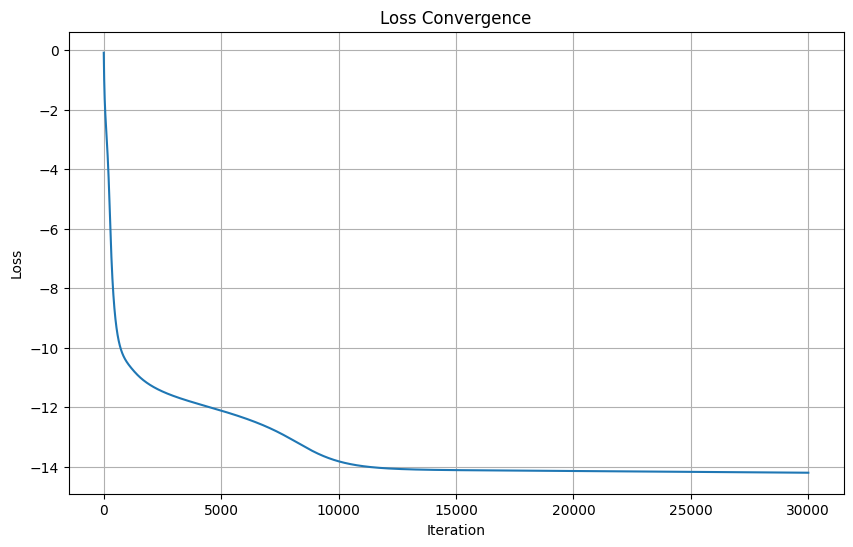

In [13]:
plt.figure(figsize=(10, 6))
plt.plot( loss_values)
plt.title('Loss Convergence')
plt.xlabel('Iteration')
plt.ylabel('Loss')
# plt.yscale('log')  # Use log scale for y-axis to better visualize the convergence
plt.grid(True)
# Show the plot (optional, you can comment this out if you don't need to display it)
plt.show()

# # Create a descriptive filename
# folder_filename = f"2d_mu1_{mu1[0]:.1f}_{mu1[1]:.1f}_mu2_{mu2[0]:.1f}_{mu2[1]:.1f}"

# convergence_filename = f"free_dofs_{len(non_marginalized_dofs)}_marginalized_dofs_{len(marginalized_dofs)}_"
# convergence_filename += f"k_lin_opt_{'yes' if design_mask[0]==1 else 'no'}_"
# convergence_filename += f"k_duff_opt_{'yes' if design_mask[1]==1 else 'no'}_"
# convergence_filename += f"c_lin_opt_{'yes' if design_mask[2]==1 else 'no'}_"
# convergence_filename += f"c_optomech_opt_{'yes' if design_mask[3]==1 else 'no'}_"
# convergence_filename += f"numSamples_{n_samples}_numIterations_{num_iterations}_finalLoss_{loss_values[-1]:.2f}_convergence.png"


# # Create the folder if it doesn't exist
# folder_path = f'results/{folder_filename}'
# os.makedirs(folder_path, exist_ok=True)

# # Save the figure
# plt.savefig(f'{folder_path}/{convergence_filename}', dpi=300, bbox_inches='tight')





In [14]:
# Calculate energy values for original k
energy_values_original = vmap(lambda x1, x2: -sign_hess*energy_network_marg(jnp.array([x1, x2]).T, k_lin, k_duff, c_lin, c_optomech, connectivity,k_b,T))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate energy values for optimized k
energy_values_optimized = vmap(lambda x1, x2: -sign_hess*energy_network_marg(jnp.array([x1, x2]).T, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity,k_b,T))(X1.ravel(), X2.ravel())
energy_values_optimized = energy_values_optimized.reshape(X1.shape)

prob_from_energy_vals_fn = vmap(lambda x: jnp.exp(sign_hess*energy_network_marg(x, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity,k_b,T))) #(X1.

X = jnp.stack([X1.ravel(), X2.ravel()], axis=-1)

# Apply the function to the combined array
prob_from_energy_vals = prob_from_energy_vals_fn(X)

# Reshape the result back to the original shape
prob_from_energy_vals = prob_from_energy_vals.reshape(X1.shape)


inegrator_norm = setup_integration(non_marginalized_dofs, integration_limits=integration_limits, num_integration_points=num_integration_points)

vol_elt = ((integration_limits[1] - integration_limits[0]) / num_integration_points) **2
norm_const_opt = jnp.sum(jnp.exp(-prob_from_energy_vals))*vol_elt

prob_from_energy_normalized = prob_from_energy_vals/norm_const_opt


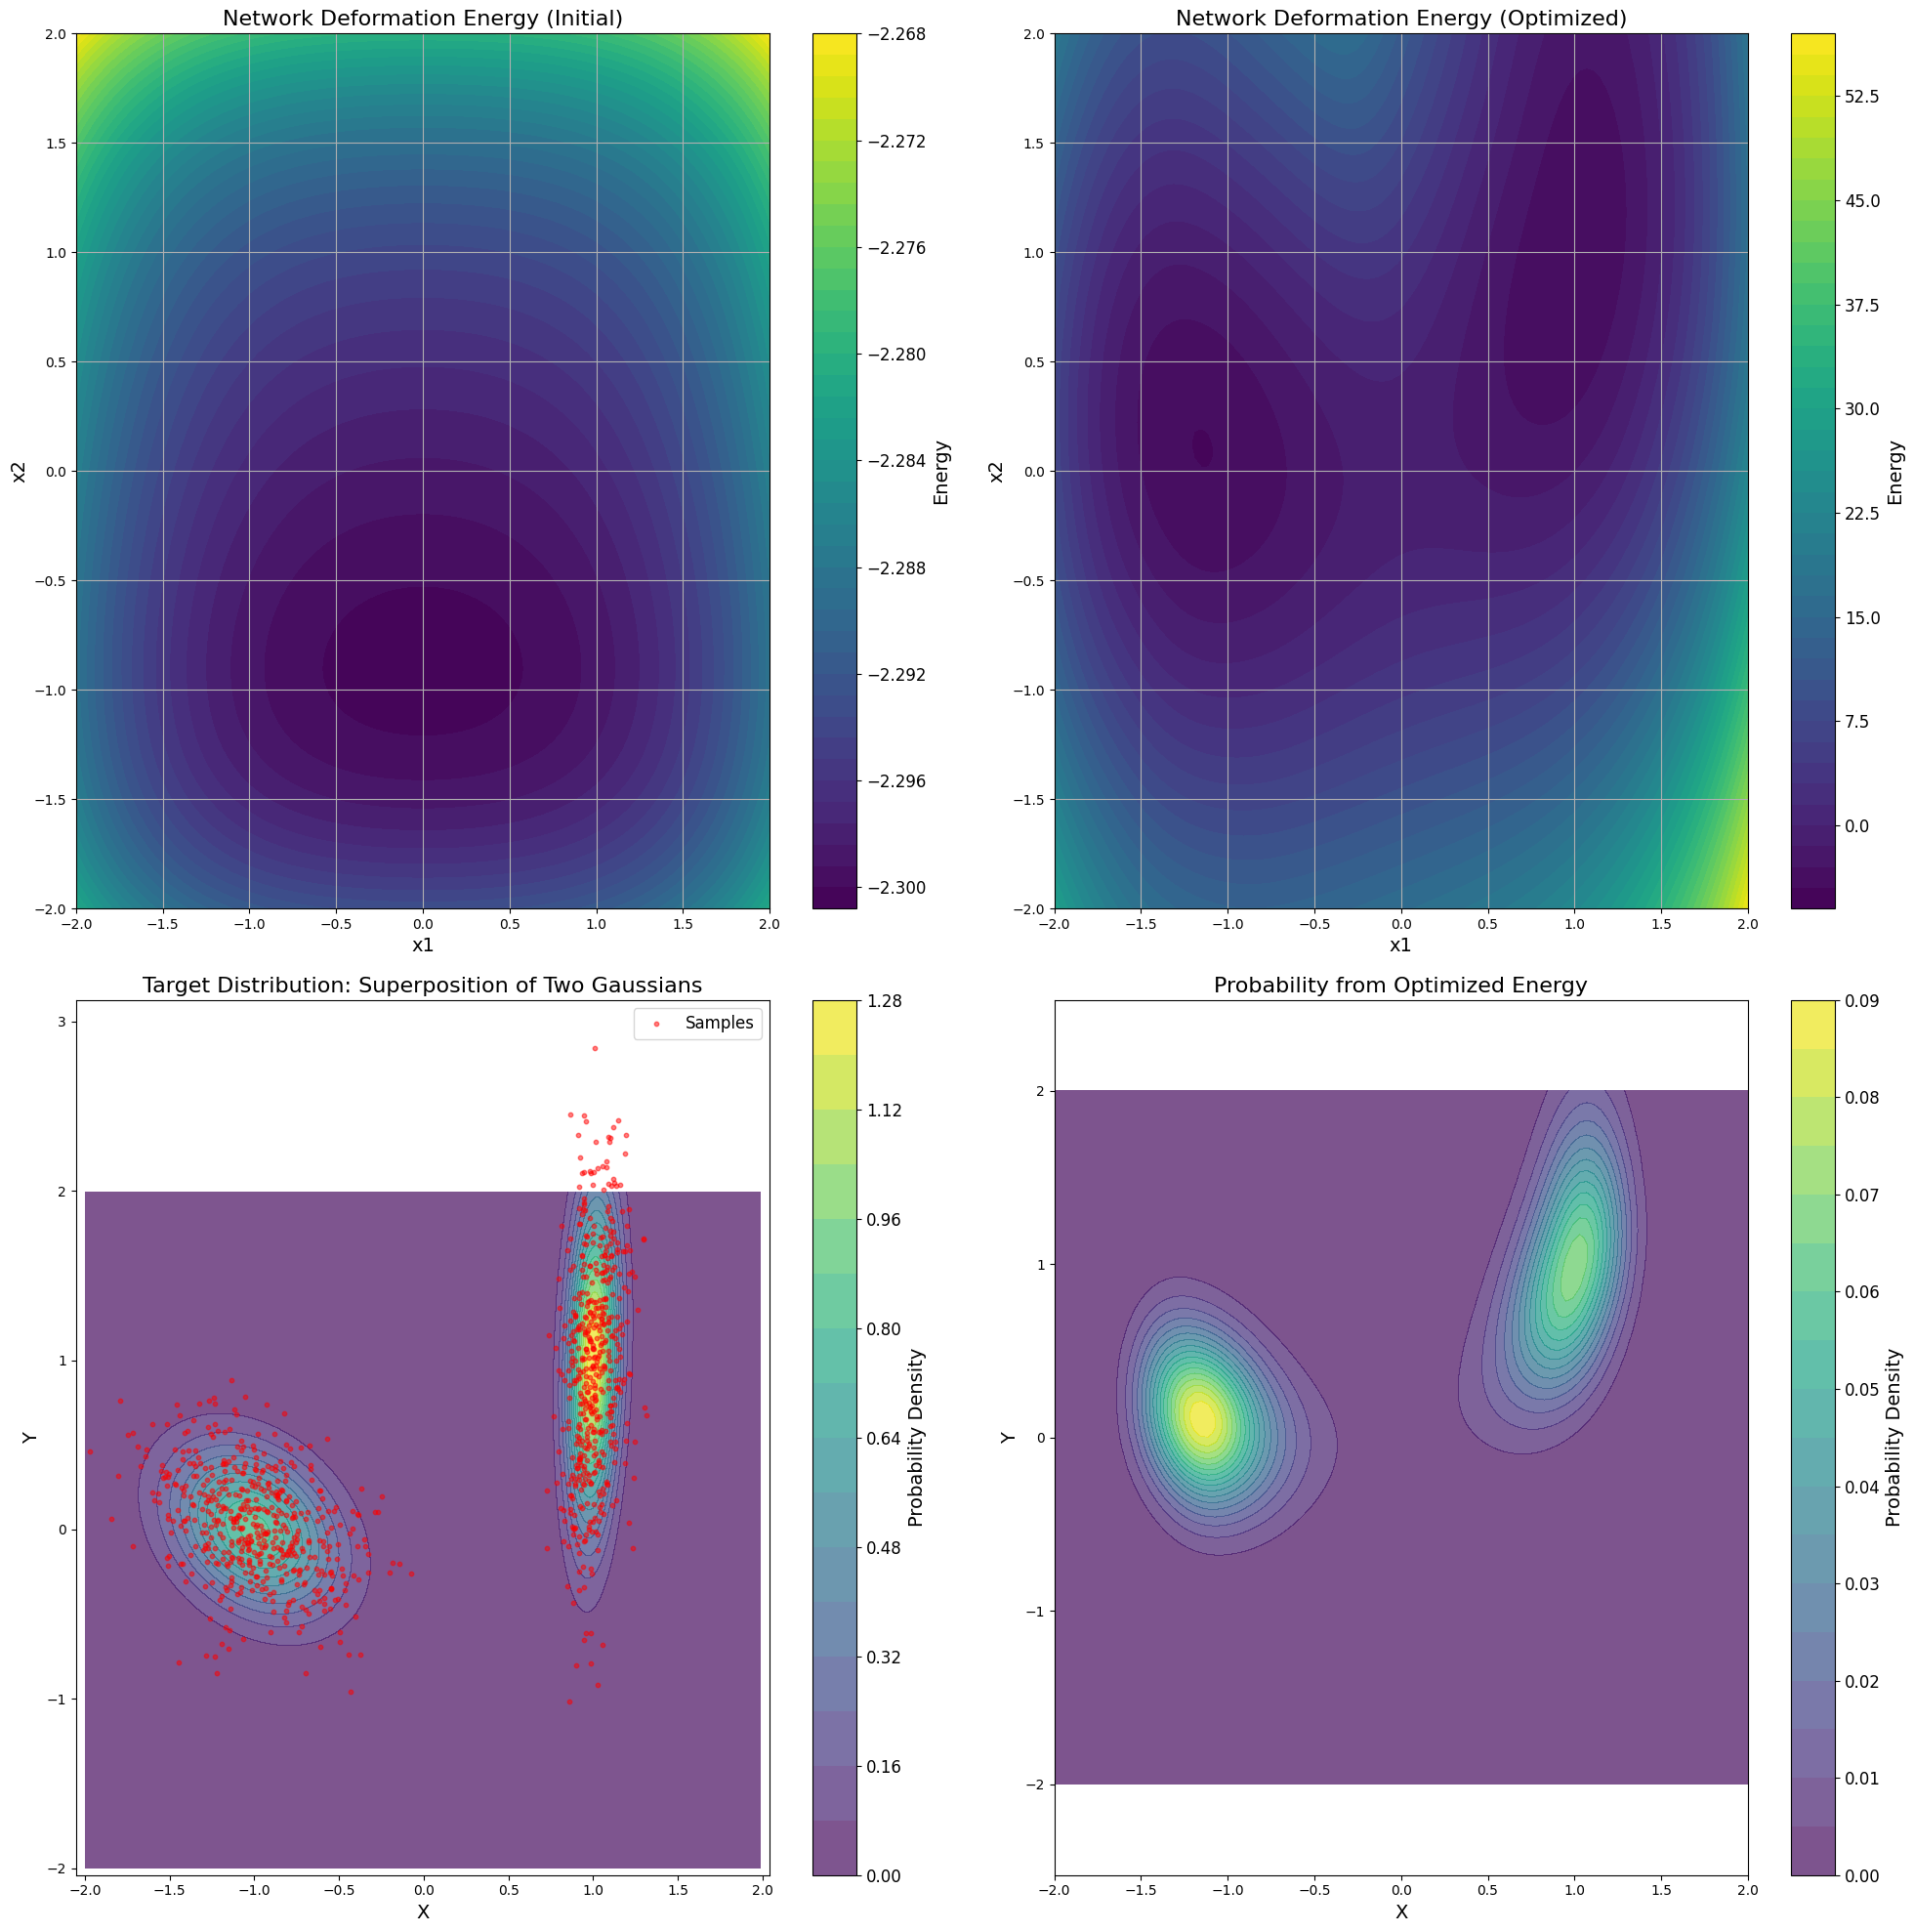

Original k_lin: [1. 1. 1.], k_duff: [1. 1. 1.], c_lin: [0. 0.], c_optomech: [1. 1.]
Optimized k_lin: [ 1335.6998 -5119.987   4098.15  ], k_duff: [2343.9277   907.47296 -418.0096 ], c_lin: [3501.9744  533.9826], c_optomech: [ 492.3586  -859.08386]


In [15]:
# ... (previous code remains the same)

# Create 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20))

# Increase font size for all text elements
plt.rcParams.update({'font.size': 14})

# Plot original k energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
cbar1 = fig.colorbar(contour1, ax=ax1)
cbar1.set_label('Energy', fontsize=14)
ax1.set_title("Network Deformation Energy (Initial)", fontsize=16)
ax1.set_xlabel("x1", fontsize=14)
ax1.set_ylabel("x2", fontsize=14)
ax1.grid(True)

# Plot optimized k energy
contour2 = ax2.contourf(X1, X2, energy_values_optimized, levels=50, cmap='viridis')
cbar2 = fig.colorbar(contour2, ax=ax2)
cbar2.set_label('Energy', fontsize=14)
ax2.set_title("Network Deformation Energy (Optimized)", fontsize=16)
ax2.set_xlabel("x1", fontsize=14)
ax2.set_ylabel("x2", fontsize=14)
ax2.grid(True)

# Plot target distribution
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)
z = p1 * z1 + (1 - p1) * z2

contour3 = ax3.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
cbar3 = fig.colorbar(contour3, ax=ax3)
cbar3.set_label('Probability Density', fontsize=14)
ax3.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')
ax3.set_title('Target Distribution: Superposition of Two Gaussians', fontsize=16)
ax3.set_xlabel('X', fontsize=14)
ax3.set_ylabel('Y', fontsize=14)
ax3.legend(fontsize=12)
ax3.axis('equal')

# Plot probability from optimized energy
contour4 = ax4.contourf(X1, X2, prob_from_energy_normalized, levels=20, cmap='viridis', alpha=0.7)
cbar4 = fig.colorbar(contour4, ax=ax4)
cbar4.set_label('Probability Density', fontsize=14)
ax4.set_title('Probability from Optimized Energy', fontsize=16)
ax4.set_xlabel('X', fontsize=14)
ax4.set_ylabel('Y', fontsize=14)
ax4.axis('equal')
# ax4.set_xlim(x_lim, -x_lim)
# ax4.set_ylim(y_lim, -y_lim)

# Increase font size for colorbar labels
for cbar in [cbar1, cbar2, cbar3, cbar4]:
    cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

# filename = convergence_filename.replace("_convergence.png", ".png")

# # Save the figure to the results folder
# plt.savefig(f'results/{folder_filename}/{filename}', dpi=300, bbox_inches='tight')

plt.show()


# Print k values for reference
print(f"Original k_lin: {k_lin}, k_duff: {k_duff}, c_lin: {c_lin}, c_optomech: {c_optomech}")
print(f"Optimized k_lin: {k_lin_opt}, k_duff: {k_duff_opt}, c_lin: {c_lin_opt}, c_optomech: {c_optomech_opt}")